# 27. Multiple Linear Regression — Hands-On with scikit-learn

Multiple Linear Regression is the extension of Simple Linear Regression (see [`25_Simple_Linear_Regression.MD`](25_Simple_Linear_Regression.MD) and [`26_Simple_Linear_Regression.ipynb`](26_Simple_Linear_Regression.ipynb)) to more than one predictor. Instead of one `x` predicting `y`, we now have several input columns predicting one output column — the equation grows from `y = m·x + c` to `y = m1·x1 + m2·x2 + c`.

`regression_dataset.csv` has three columns — `Age`, `Experience`, `Salary` — for 1000 people. `Salary` is what we want to predict; `Age` and `Experience` are the two predictor variables.

This notebook walks the full flow: load the data, look at it (a pairplot and a correlation heatmap this time, since there's more than one relationship to check), split it into inputs/target, train a `LinearRegression` model on two predictors at once, read back what it learned, and finish with two charts that show how good the fit actually is.

In [1]:
import pandas as pd                                   # pandas: load the CSV and work with it as a table (DataFrame)
import seaborn as sns                                  # seaborn: nicer statistical plots (pairplot, heatmap), built on matplotlib
import matplotlib.pyplot as plt                        # matplotlib: base plotting library, used for titles/labels/showing figures
from sklearn.model_selection import train_test_split   # splits our data into a training pool and a held-back testing pool
from sklearn.linear_model import LinearRegression      # the model class — now fitting more than one predictor at once

## Step 1 — Load the dataset

In [2]:
dataset = pd.read_csv("regression_dataset.csv")  # read the CSV file from disk into a pandas DataFrame called "dataset"

## Step 2 — Peek at the first few rows

In [3]:
dataset.head(3)  # show only the first 3 rows, just to eyeball the columns and their values

,Age,Experience,Salary
0,25,4,30794
1,52,23,103892
2,47,15,75315


## Step 3 — Check the shape

In [4]:
dataset.shape  # (rows, columns) — confirms 1000 people, 3 columns

(1000, 3)

## Step 4 — Check for missing values

Same habit as every earlier `ML/` topic and [`26_Simple_Linear_Regression.ipynb`](26_Simple_Linear_Regression.ipynb): before training anything, confirm there are no gaps. `scikit-learn` cannot train on missing (`NaN`) values.

In [5]:
dataset.isnull().sum()  # count missing values per column — all 0 here, since this dataset was generated clean

Age           0
Experience    0
Salary        0
dtype: int64

## Step 5 — Visualize how every column relates to every other (pairplot)

With Simple Linear Regression there was only one `x`, so a single scatter plot showed the whole relationship. Now that there are two predictors (`Age`, `Experience`) plus the target (`Salary`), a `pairplot` is the equivalent tool: it draws a scatter plot for every pair of columns, and a histogram for each column against itself on the diagonal. It's a fast way to eyeball whether `Salary` roughly rises with `Age` and `Experience`, and whether the two predictors already look related to each other before the model ever sees them.

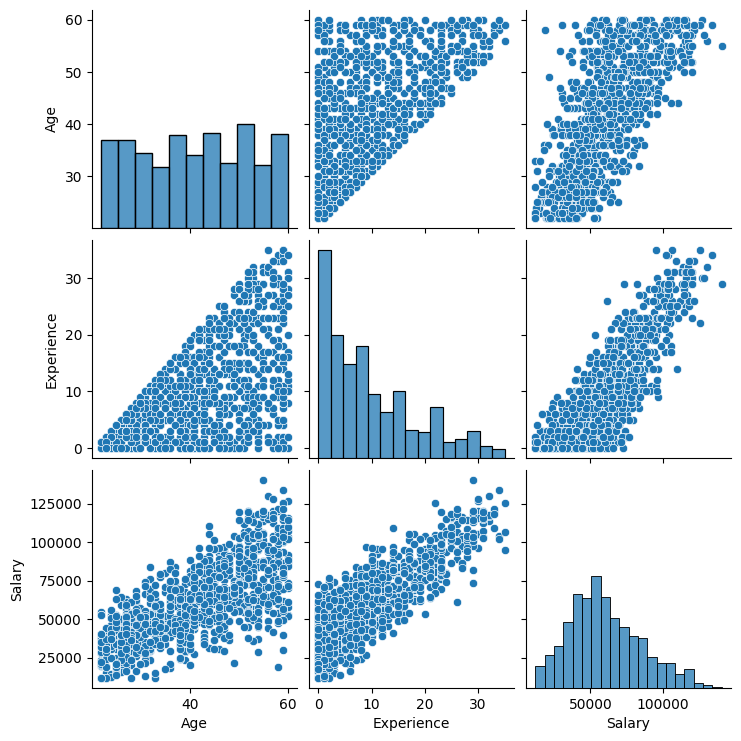

In [6]:
sns.pairplot(data=dataset)   # scatter every column against every other column, histogram on the diagonal
plt.show()                   # render the grid of plots

## Step 6 — Quantify those relationships (correlation heatmap)

The pairplot shows relationships visually; a correlation heatmap puts a number on each one. Correlation ranges from `-1` (perfectly opposite) to `+1` (perfectly together), with `0` meaning no straight-line relationship at all. `annot=True` prints the actual number inside each cell. What matters most here is how strongly `Age` and `Experience` each correlate with `Salary` — that's what the model leans on — and, as a side note, how strongly `Age` and `Experience` correlate with *each other*. Two predictors that are too similar to one another give the model overlapping, less useful information — a topic called multicollinearity, worth knowing exists but not something we need to solve here.

<Axes: >

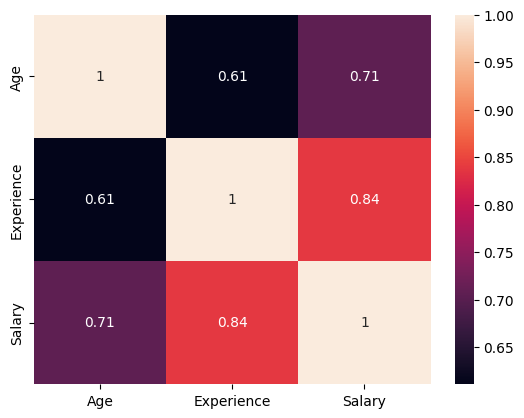

In [7]:
sns.heatmap(data=dataset.corr(), annot=True)   # dataset.corr() computes the correlation table; heatmap colors + prints each value

## Step 7 — Split into inputs (`x`) and target (`y`)

Same idea as Simple Linear Regression, just wider: `x` needs to hold *both* predictor columns now, not one. `dataset.iloc[:, :-1]` is positional slicing — "every row, every column except the last one" — a habit worth having since it works no matter how many predictor columns a dataset has. `y` stays a single column, same as before.

In [8]:
x = dataset.iloc[:, :-1]   # every row, every column except the last ("Salary") — this is now a 2-column table
x                          # display it, to see what we just built

,Age,Experience
0,25,4
1,52,23
2,47,15
3,39,16
4,38,2
...,...,...
995,46,0
996,42,12
997,36,15
998,59,10


## Step 8 — Confirm `x` is already 2-D

In [`26_Simple_Linear_Regression.ipynb`](26_Simple_Linear_Regression.ipynb), `x` was a single column (a 1-D Series) and had to be manually reshaped into a 2-D table before `scikit-learn` would accept it. Here, `x` already has two columns, so pandas hands it back as a 2-D DataFrame automatically — no reshaping needed. `.ndim` confirms that: `2` means "a table with rows and columns," which is the shape (`n_samples, n_features`) every `scikit-learn` model expects for its inputs.

In [9]:
x.ndim   # 2 = already a 2-D table (rows x columns) — no reshape needed, unlike the single-column case

2

## Step 9 — Pull out `y` (the target)

In [10]:
y = dataset["Salary"]   # pull out just the "Salary" column — this is what the model will learn to predict
y                        # display it, to see what we just built

0       30794
1      103892
2       75315
3       67706
4       43926
        ...  
995     43949
996     63166
997     58387
998     80121
999     55561
Name: Salary, Length: 1000, dtype: int64

## Step 10 — Sanity-check the shape

A quick re-check that slicing `x` and `y` out of `dataset` didn't accidentally drop or duplicate any rows — still 1000 rows, 3 original columns in the source data.

In [11]:
dataset.shape   # still (1000, 3) — slicing into x and y doesn't change the original dataset

(1000, 3)

## Step 11 — Split into train and test sets

`train_test_split` holds back 20% of the rows (`test_size=0.2`) as a test set the model never sees during training. That's the only fair way to check later whether the model actually learned the pattern, or just memorized the training rows. `random_state=42` fixes the shuffle so the split is reproducible — same rows in train/test every time this notebook re-runs.

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   # 80% train, 20% held back for testing

## Step 12 — Train the model

`.fit()` is where the actual learning happens: `scikit-learn` searches for the `m1`, `m2`, and `c` that make `y = m1·Age + m2·Experience + c` fit the *training* rows as closely as possible — same least-squares idea as Simple Linear Regression, just solving for two slopes instead of one.

In [13]:
lr = LinearRegression()      # create an (untrained) Linear Regression model
lr.fit(x_train, y_train)     # train it — this step learns m1, m2, and c from the training rows

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 719.08,1784.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Age','Experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.343e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


## Step 13 — Score the model on unseen data

`.score()` on regression models returns R² — the fraction of the variation in `Salary` that `Age` and `Experience` together explain, on the *test* rows the model never trained on. Multiplying by 100 turns it into a percentage. An R² of ~75% means the two predictors explain about three-quarters of why salaries differ in this data; the rest comes from the random noise baked into how this dataset was generated (in a real dataset, it would be other factors the two columns don't capture) — same caveat as any regression. Backend analogy: like test coverage, but for how well a formula predicts outcomes rather than how much code got run.

In [14]:
lr.score(x_test, y_test) * 100   # R² on the test set, as a percentage — how much of Salary's variation Age+Experience explain

75.26418389841064

## Step 14 — The general equation

Simple Linear Regression fit a line: `y = m·x + c`. Multiple Linear Regression fits a flat plane (or higher-dimensional equivalent) instead: one slope per predictor, all added together, plus one intercept.

In [15]:
#y = m1x1 + m2x2 + c

## Step 15 — Look at the learned coefficients (the slopes)

`lr.coef_` returns one number per predictor, **in the same order as `x`'s columns**. Each number is that predictor's `m`: "holding the other predictor fixed, how much does `Salary` change for every +1 unit of this one?"

In [16]:
lr.coef_   # [m1, m2] — one slope per predictor column, in the same order as x.columns

array([ 719.07681097, 1784.49764362])

## Step 16 — Look at the intercept

`lr.intercept_` is `c` — the model's predicted `Salary` when *every* predictor is 0. As with Simple Linear Regression's intercept, treat this as a mathematical anchor for the line/plane, not a literal prediction: nobody in this dataset has `Age = 0`, so this number is an extrapolation outside the real data, not a meaningful salary on its own.

In [17]:
lr.intercept_   # c — the fitted plane's value when Age = 0 and Experience = 0 (an extrapolation, not a real scenario)

np.float64(13428.445576810147)

## Step 17 — Confirm which coefficient belongs to which column

`lr.coef_` is a plain array with no column labels attached, so the mapping to `Age` vs `Experience` depends entirely on column *position* — like calling a function with positional args instead of named ones. `x.columns` confirms the order: `coef_[0]` → `Age`, `coef_[1]` → `Experience`.

In [18]:
x.columns   # confirms coef_[0] belongs to Age and coef_[1] belongs to Experience, in this order

Index(['Age', 'Experience'], dtype='str')

## Step 18 — Write out the fitted equation with real numbers

Plugging `lr.coef_` and `lr.intercept_` into `y = m1·x1 + m2·x2 + c` gives the actual formula this model learned — every prediction below is just this line of arithmetic run on a row's `Age` and `Experience`.

In [19]:
# y_prd = 719.07681097*Age + 1784.49764362*Experience + 13428.445576810147

## Step 19 — Predict on the test set

`.predict()` runs that exact equation on every row of `x_test` and returns the predicted salaries — one number per test row, ready to compare against the real `y_test` values.

In [20]:
lr.predict(x_test)   # run the fitted equation on every test row — returns 200 predicted salaries

array([ 39981.51004756,  40380.63160446,  76522.48356907,  40700.58685853,
        43923.2381241 ,  79319.62451012,  52872.11510983,  69384.49299458,
        94367.46000531,  77907.85965579,  94740.1927946 ,  53937.53594248,
        37504.32436057,  52898.50387744,  76096.97324455,  60781.96003052,
        50714.88467691,  44269.58214578,  60409.22724123,  71515.33465988,
        47944.13250348,  48663.20931445,  63285.53448512,  32843.51947306,
        48930.38703329,  67227.26256166,  41419.6636695 ,  83980.42939763,
        47492.23341134,  43550.5053348 , 110107.98354386,  59317.41764097,
        42191.5180157 ,  67520.82904811,  61794.60332795,  60010.10568432,
        63631.8785068 ,  57879.26401902,  31751.7098728 ,  62220.11365247,
        39981.51004756,  51780.30550956,  39262.43323658,  38197.01240393,
        29248.1354182 ,  93648.38319434,  41073.31964782,  91863.88555071,
        68586.24988076,  37850.66838225,  59422.97271142,  50074.97416878,
        46054.0797894 ,  

## Step 20 — Visualize actual vs. predicted salary

With one predictor, Simple Linear Regression's fit could be drawn as a single line through a scatter plot. With two predictors, there's no single line or 2-D plot that shows the fit directly. The standard workaround: plot every test row's **actual** `Salary` on the x-axis against its **predicted** `Salary` on the y-axis. A perfect model would put every point exactly on the diagonal line; the tighter the cloud of points hugs that diagonal, the better the model.

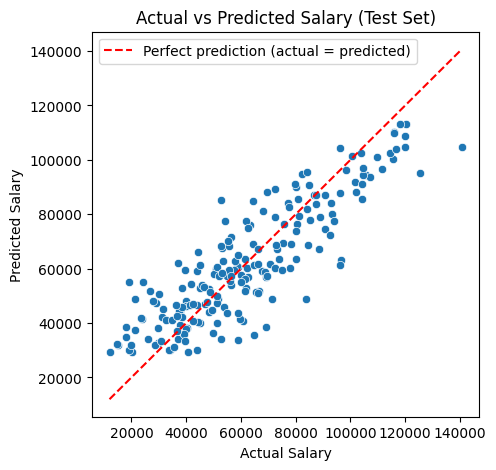

In [21]:
y_pred = lr.predict(x_test)   # predicted salaries for every test row (same call as Step 19, saved this time for reuse below)

plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred)                                          # actual salary on x, predicted salary on y
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]    # shared axis limits so the diagonal spans the full plot
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction (actual = predicted)")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Test Set)")
plt.legend()
plt.show()

## Step 21 — Visualize which predictor moves salary more

`lr.coef_` already gave the two slopes as numbers; a bar chart makes the comparison easier to read at a glance. One caveat worth flagging: `Age` (roughly 22–60) and `Experience` (roughly 0–35) sit on different scales, so comparing raw coefficient size is only a rough guide here, not a precise "feature importance" ranking — putting both predictors on the same scale first (see [`16_Feature_Scaling_Normalization.ipynb`](16_Feature_Scaling_Normalization.ipynb)) would make this comparison fully fair.

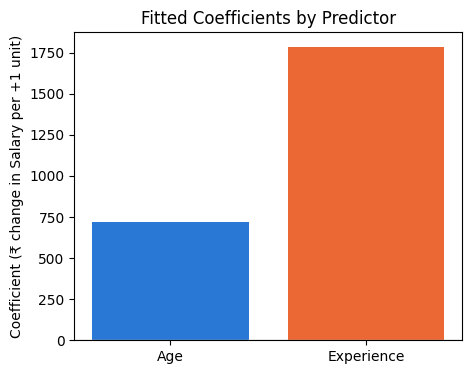

In [22]:
plt.figure(figsize=(5, 4))
plt.bar(x.columns, lr.coef_, color=["#2a78d6", "#eb6834"])   # one bar per predictor, height = its fitted slope
plt.axhline(0, color="#c3c2b7", linewidth=1)                 # baseline for reference
plt.ylabel("Coefficient (₹ change in Salary per +1 unit)")
plt.title("Fitted Coefficients by Predictor")
plt.show()

## Key Takeaways

- Multiple Linear Regression just widens the equation: `y = m·x + c` becomes `y = m1·x1 + m2·x2 + ... + c`, one slope per predictor.
- With 2+ predictor columns, `x` is already 2-D — no manual reshape needed, unlike the single-predictor case in [`26_Simple_Linear_Regression.ipynb`](26_Simple_Linear_Regression.ipynb).
- `lr.coef_` has no column labels — it's matched to `x.columns` purely by *position*, so always confirm the order before reading the numbers.
- R² (`.score()`) tells you how much of the target's variation the predictors explain overall — it doesn't tell you which single predictor deserves the credit.
- With one predictor you can draw the fit as a line; with two or more, "actual vs predicted" is the standard way to *see* how well a multi-predictor model fits.
- Comparing raw coefficients across predictors is only fair once they're on the same scale — otherwise a big coefficient might just mean "small units," not "more important."

## FAQ

**Q: `scikit-learn` already has `.fit()` and `.predict()` — why learn all the underlying concepts? Isn't everything going forward just going to be library calls?**

Mostly yes — going forward, real work almost always means calling a library (`scikit-learn` now, `PyTorch` / `HuggingFace` later for the GenAI phase of this roadmap), not hand-writing gradient descent. That part doesn't go away. But the library only does the "turn the crank" step: given `x_train`, `y_train`, and a chosen algorithm, it computes the numbers. It cannot decide *which* algorithm fits the problem, cannot explain *why* a result is bad, and cannot fix a data problem it doesn't know exists — that judgment is exactly what the concepts are for.

Backend analogy: nobody reimplements `HashMap` or Spring's `DispatcherServlet` — but understanding hashing and the request lifecycle is still what lets you debug a slow map or a controller that's silently never invoked. `lr.fit()` / `lr.predict()` sit exactly where a Spring Data repository's `save()` / `findById()` sit: trivial to call, useless to debug or design around without knowing what's happening underneath.

Concretely, right in this notebook: the model scored ~75% R² (Step 13), not 100%. `scikit-learn` doesn't say whether that's *good* or a sign something's wrong — only understanding what R² measures, and what could be dragging it down (noise, a missing predictor, bad data), answers that.

Where the concepts earn their keep even though the library does the arithmetic:
- **Picking the right algorithm** for the data — linear vs. tree-based vs. neural net. `scikit-learn` offers dozens; nothing picks for you.
- **Diagnosing a bad result** — wrong scaling, data leakage, overfitting, the wrong evaluation metric.
- **Tuning hyperparameters** on purpose instead of blind grid search.
- **Preparing data correctly** (scaling, encoding, outliers) *before* it reaches `.fit()` — the library trusts that was done right.

On "for complicated data, don't we need to build it from scratch?" — no: `scikit-learn` and libraries like `XGBoost` handle massive real production tabular data as-is (fraud detection, credit scoring, recommendation systems all run on them). Implementing an algorithm from scratch is a one-time *teaching* exercise to build intuition for what `.fit()` is doing internally — the same reason a CS course has you implement a linked list once, even though production Java code never hand-rolls one. It's not what ships.

The reasoning skill this phase is building — is this model appropriate, is this result trustworthy, why did it fail — doesn't expire when the library changes. It's the same skill that later shows up as judging RAG retrieval quality, evaluating LLM outputs, or deciding fine-tune vs. prompt in the GenAI phase of the roadmap.